## 路径配置

In [36]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [37]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SCRIPT_DIR = Path(os.getcwd()).parent
sys.path.append(os.path.dirname(SCRIPT_DIR))

In [38]:
from minsted.simulators import MinstedSimulator
from minsted.fluorophores import FlStatic

In [39]:
#  实例化分子
fl = FlStatic()  # define a static fluorophore
fl.pos = [10, 0] # 假设分子在真实空间绝对坐标 [10nm, 0nm]
fl.brightness = 1000 # kHz 基准亮度

# 2. 初始化 MinstedSimulator (请根据你定义的构造函数参数调整)
# 假设初始圆周扫描半径 R=250nm，激光参数 gamma，全局背景噪声 bg_global=2.0 kHz
sim = MinstedSimulator(d0=250.0, alpha=0.15, gamma=0.97, r_min=5.0, d_min=40.0)

# 3. 设定仿真时间步长与总时长
dt = 0.05  # 每一仿真步的时间窗（时间分辨率），单位：ms (50微秒)
total_steps = 1000  # 总共跑 1000 步
current_time = 0.0

In [40]:
# 记录追踪历史用于后续画图收敛曲线
estimated_positions = []
true_positions = []

In [1]:
print("开始 MINSTED 静止分子定位追踪...")

for step in range(total_steps):
    mol_pos_3d, _ = fl.position(current_time)
    mol_pos_2d = mol_pos_3d[:2]

    # ✨ 核心物理更新：直接获取基于双光束叠加的有效 E-PSF 发射系数（图c中的黄线高度）
    eff_psf_coeff = sim.get_effective_psf_coefficient(mol_pos_2d, time_ms=current_time)

    # 荧光分子实际产生光子的理论强度 = 分子未受抑制时的基准亮度 * 有效 E-PSF 系数
    # fl.intensity 内部会自动处理剩余光子预算和光漂白
    emitted_intensity = fl.intensity(I0=eff_psf_coeff, dwelltime=dt, time=current_time, phfac=1.0)

    # 蒙特卡洛抽样：探测器看到的实际光子数
    expected_photons = emitted_intensity + (sim.bg_global * dt)
    detected_photons = np.random.poisson(expected_photons)

    # 闭环反馈：如果探测到光子，注册当前的 EOD 坐标并迭代
    if detected_photons > 0:
        s_i_snap = sim.get_current_eod_position(current_time)
        for _ in range(detected_photons):
            sim.register_one_photon(s_i=s_i_snap, origin="SIGNAL")

    # 记录数据...
    current_time += dt
print(f"定位结束！分子真实位置: {fl.pos[:2]}, 算法最终估计位置: {sim.C_i}")

开始 MINSTED 静止分子定位追踪...


NameError: name 'total_steps' is not defined

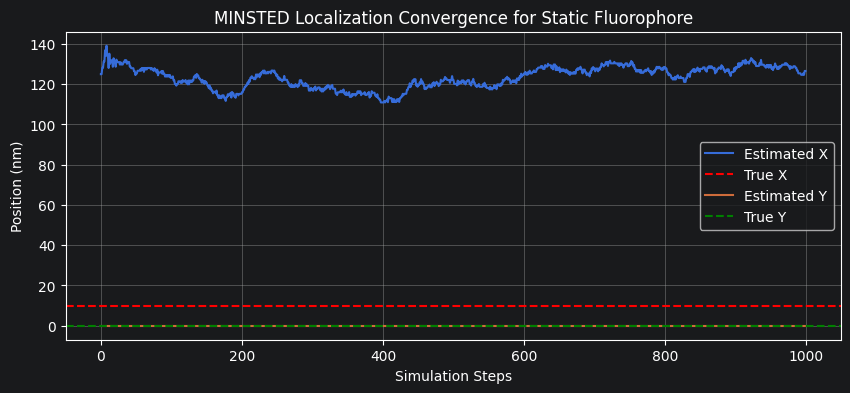

In [35]:
#  可视化定位收敛曲线
est_pos = np.array(estimated_positions)
plt.figure(figsize=(10, 4))
plt.plot(est_pos[:, 0], label="Estimated X")
plt.axhline(y=fl.pos[0], color='r', linestyle='--', label="True X")
plt.plot(est_pos[:, 1], label="Estimated Y")
plt.axhline(y=fl.pos[1], color='g', linestyle='--', label="True Y")
plt.xlabel("Simulation Steps")
plt.ylabel("Position (nm)")
plt.title("MINSTED Localization Convergence for Static Fluorophore")
plt.legend()
plt.grid(True)
plt.show()